## All experimented loss type

<small>1. MS</small>  
<small>2. CONTRASTIVE</small>  
<small>3. CIRCLE</small>

In [16]:
LOSS_TYPE_MS = "MS"
LOSS_TYPE_CONTRASTIVE = "CONTRASTIVE"
LOSS_TYPE_CIRCLE = "CIRCLE"
LOSS_TYPE = "MS"

# Library Import

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import random
import numpy as np
import torch
from src.preprocessing.dataLoader_Siamase import SiameseNetworkDataset
from src.ml.resNet18 import SiameseNetworkCosine, SiameseNetworkContrastive

In [18]:
def set_seed(seed=42):
    """Set all random seeds for reproducibility"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Set seed before any operations
#set_seed(20)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Network

In [19]:
contrastive = False
if LOSS_TYPE == "CONTRASTIVE":
    model_path = "models/models_contrastive/best_model_overall.pt"
    net = SiameseNetworkContrastive().to(DEVICE)

elif LOSS_TYPE == "MS":
    model_path = "models/models_ms/models_ms_40_80/best_model_overall.pt"
    net = SiameseNetworkCosine().to(DEVICE)
else:
    model_path = "models/models_circle/best_model_overall.pt"
    net = SiameseNetworkCosine().to(DEVICE)
net.load_state_dict(torch.load(model_path, map_location=DEVICE), strict=False)

<All keys matched successfully>

In [20]:
# If you want reproducible DataLoader shuffling, create a torch.Generator with fixed seed:
g = torch.Generator()
g.manual_seed(42)

# Your transformations and dataset
transformation_test = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()
])

root = "dataset/test/AT&T/"
#root = "dataset/test/CelebA/"
#root = "dataset/test/VGGface/"
folder_dataset_test = datasets.ImageFolder(root=root)
test_dataset = SiameseNetworkDataset(imageFolderDataset=folder_dataset_test,
                                     transform=transformation_test)

test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True, num_workers=0, generator=g)


✅ Average Intra-Class Distance: 0.7369
✅ Average Inter-Class Distance: 0.0766


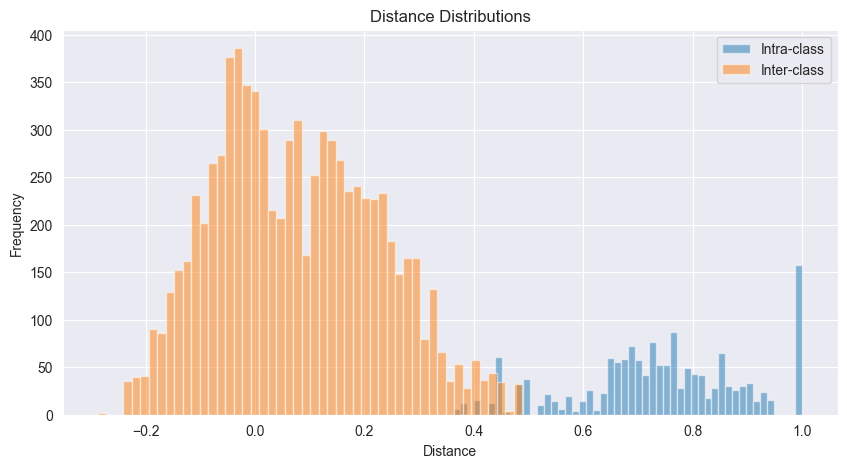

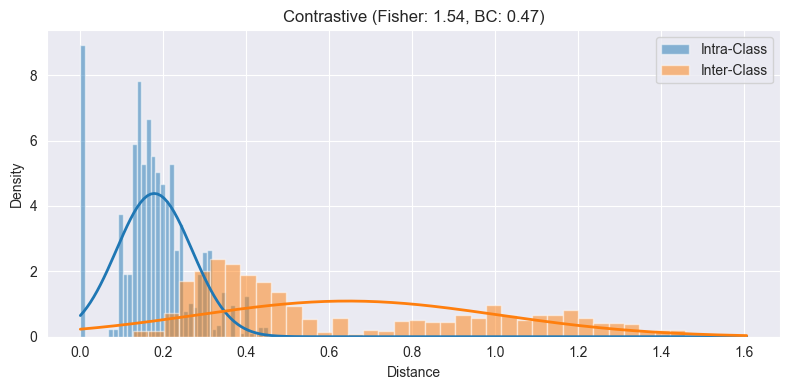

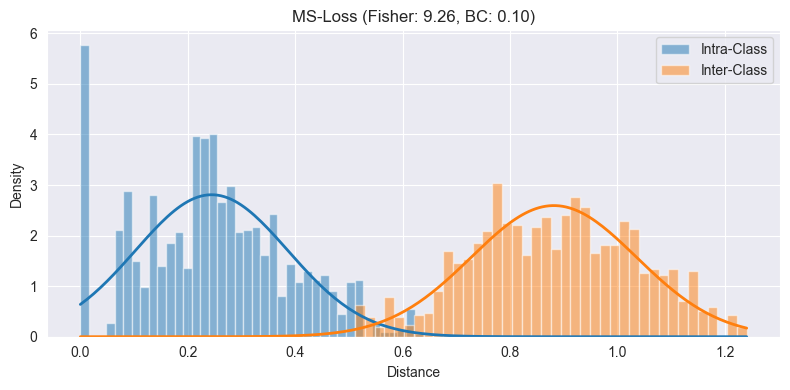

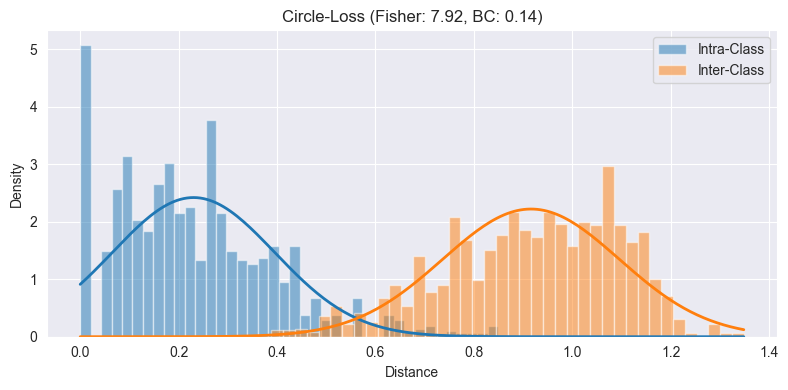

             mu_intra  mu_inter  sd_intra  sd_inter    fisher  bhattacharyya
Contrastive  0.178072  0.645055  0.091042  0.365624  1.536054       0.466425
MS-Loss      0.244447  0.881645  0.142049  0.153796  9.263293       0.098529
Circle-Loss  0.230287  0.916016  0.164718  0.179541  7.920663       0.137791
Bestes Modell nach Fisher-Ratio: MS-Loss


In [21]:
from collections import defaultdict
from itertools import combinations
import torch.nn.functional as F

# Set model to evaluation mode
net.eval()

# Collect embeddings and labels from validation set
all_embeddings = []
all_labels = []

with torch.no_grad():
    for img0, img1, _, label0, label1 in test_dataloader:
        img0, img1 = img0.to(DEVICE), img1.to(DEVICE)
        label0, label1 = label0.to(DEVICE), label1.to(DEVICE)
        output1, output2 = net(img0, img1)

        all_embeddings.append(torch.cat([output1, output2]))
        all_labels.append(torch.cat([label0, label1]))

# Concatenate all embeddings and labels
all_embeddings = torch.cat(all_embeddings)  # shape: [N, D]
all_labels = torch.cat(all_labels)          # shape: [N]

# Group embeddings by class
class_to_embeddings = defaultdict(list)
for emb, label in zip(all_embeddings, all_labels):
    class_to_embeddings[label.item()].append(emb)

for key in class_to_embeddings:
    class_to_embeddings[key] = torch.stack(class_to_embeddings[key])

# Compute intra-class distances
intra_dists = []
for emb_list in class_to_embeddings.values():
    for i, j in combinations(range(len(emb_list)), 2):
        if LOSS_TYPE == "CONTRASTIVE":
            dist = F.pairwise_distance(emb_list[i].unsqueeze(0), emb_list[j].unsqueeze(0))
        else:
            dist = F.cosine_similarity(emb_list[i].unsqueeze(0), emb_list[j].unsqueeze(0))
        intra_dists.append(dist.item())

# Compute inter-class distances
inter_dists = []
label_keys = list(class_to_embeddings.keys())
for i in range(len(label_keys)):
    for j in range(i+1, len(label_keys)):
        emb_i = class_to_embeddings[label_keys[i]]
        emb_j = class_to_embeddings[label_keys[j]]
        for e1 in emb_i:
            for e2 in emb_j:
                if LOSS_TYPE == "CONTRASTIVE":
                    dist = F.pairwise_distance(e1.unsqueeze(0), e2.unsqueeze(0))
                else:
                    dist = F.cosine_similarity(e1.unsqueeze(0), e2.unsqueeze(0))
                inter_dists.append(dist.item())

# Compute statistics
avg_intra = sum(intra_dists) / len(intra_dists)
avg_inter = sum(inter_dists) / len(inter_dists)

print(f"✅ Average Intra-Class Distance: {avg_intra:.4f}")
print(f"✅ Average Inter-Class Distance: {avg_inter:.4f}")

# Optional: Visualize distributions
plt.figure(figsize=(10, 5))
plt.hist(intra_dists, bins=50, alpha=0.5, label='Intra-class')
plt.hist(inter_dists, bins=50, alpha=0.5, label='Inter-class')
plt.title("Distance Distributions")
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()



from itertools import combinations
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Für reproduzierbare Stichproben
np.random.seed(42)

# --- DEVICE, Modellklassen und test_dataloader müssen bereits definiert sein ---
# DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# class SiameseNetwork_contrastive(nn.Module): ...
# class SiameseNetwork(nn.Module): ...
# test_dataloader = ...

model_paths = {
    "Contrastive":  "models/models_contrastive/best_model_overall.pt",
    "MS-Loss":      "models/models_ms/models_ms_40_80/best_model_overall.pt",
    "Circle-Loss":  "models/models_circle/best_model_overall.pt"
}

def compute_intra_inter(dataloader, model, loss_key):
    model.eval()
    all_emb, all_lbl = [], []
    with torch.no_grad():
        for img0, img1, _, l0, l1 in dataloader:
            img0, img1 = img0.to(DEVICE), img1.to(DEVICE)
            out0, out1 = model(img0, img1)
            all_emb.append(torch.cat([out0, out1]))
            all_lbl.append(torch.cat([l0.to(DEVICE), l1.to(DEVICE)]))
    emb = torch.cat(all_emb)
    lbl = torch.cat(all_lbl)

    # Embeddings je Klasse sammeln
    cls2emb = {}
    for e, v in zip(emb, lbl):
        cls2emb.setdefault(int(v), []).append(e)
    for k in cls2emb:
        cls2emb[k] = torch.stack(cls2emb[k])

    # Distanz-/Ähnlichkeitsfunktion wählen
    if loss_key == "CONTRASTIVE":
        metric = F.pairwise_distance
        xlabel = "Distance"
    else:
        metric = lambda x, y: 1 - F.cosine_similarity(x, y)
        xlabel = "Distance"

    intra, inter = [], []
    keys = list(cls2emb.keys())

    # Intra-Klassen
    for k in keys:
        em = cls2emb[k]
        for i, j in combinations(range(len(em)), 2):
            d = metric(em[i].unsqueeze(0), em[j].unsqueeze(0))
            intra.append(d.item())

    # Inter-Klassen
    for i in range(len(keys)):
        for j in range(i+1, len(keys)):
            for e1 in cls2emb[keys[i]]:
                for e2 in cls2emb[keys[j]]:
                    d = metric(e1.unsqueeze(0), e2.unsqueeze(0))
                    inter.append(d.item())

    intra = np.array(intra)
    inter = np.array(inter)

    # Auf gleiche Anzahl beschränken
    min_len = min(len(intra), len(inter))
    if len(intra) != len(inter):
        idx_intra = np.random.choice(len(intra), min_len, replace=False)
        idx_inter = np.random.choice(len(inter), min_len, replace=False)
        intra = intra[idx_intra]
        inter = inter[idx_inter]

    return intra, inter, xlabel

def separation_metrics(intra, inter):
    mu_in, mu_it = intra.mean(), inter.mean()
    sd_in, sd_it = intra.std(), inter.std()
    fisher = (mu_it - mu_in)**2 / (sd_it**2 + sd_in**2 + 1e-8)
    # Bhattacharyya-Koeffizient
    term1 = 0.25 * np.log(0.25 * (sd_in**2 / sd_it**2 + sd_it**2 / sd_in**2 + 2))
    term2 = 0.25 * ((mu_in - mu_it)**2 / (sd_in**2 + sd_it**2 + 1e-8))
    bc = np.exp(-(term1 + term2))
    return {
        "mu_intra": mu_in,
        "mu_inter": mu_it,
        "sd_intra": sd_in,
        "sd_inter": sd_it,
        "fisher": fisher,
        "bhattacharyya": bc
    }

results = {}

for name, path in model_paths.items():
    # Modell initialisieren
    if name == "Contrastive":
        model = SiameseNetworkContrastive().to(DEVICE)
        key = "CONTRASTIVE"
    else:
        model = SiameseNetworkCosine().to(DEVICE)
        key = "MS" if name == "MS-Loss" else "CIRCLE"
    model.load_state_dict(torch.load(path, map_location=DEVICE), strict=False)

    # Distanzen berechnen (mit Balancing)
    intra_d, inter_d, xlabel = compute_intra_inter(test_dataloader, model, key)
    metrics = separation_metrics(intra_d, inter_d)
    results[name] = metrics

    # Histogramm mit Gauß-Fit
    plt.figure(figsize=(8, 4))

    # Bars mit Cycle-Farben C0/C1 und alpha=0.5
    plt.hist(intra_d, bins=40, density=True, alpha=0.5, color='C0', label='Intra-Class')
    plt.hist(inter_d, bins=40, density=True, alpha=0.5, color='C1', label='Inter-Class')

    # Bereich für PDF
    xmin = min(intra_d.min(), inter_d.min())
    xmax = max(intra_d.max(), inter_d.max())
    x = np.linspace(xmin, xmax, 200)

    # PDFs
    mu_in, sd_in = metrics['mu_intra'], metrics['sd_intra']
    mu_it, sd_it = metrics['mu_inter'], metrics['sd_inter']
    pdf_in = (1/(sd_in * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu_in)/sd_in)**2)
    pdf_it = (1/(sd_it * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu_it)/sd_it)**2)

    # Fit-Kurven in derselben Farbe, voll deckend
    plt.plot(x, pdf_in, color='C0', linewidth=2)
    plt.plot(x, pdf_it, color='C1', linewidth=2)

    plt.title(f"{name} (Fisher: {metrics['fisher']:.2f}, BC: {metrics['bhattacharyya']:.2f})")
    plt.xlabel(xlabel)
    plt.ylabel("Density")
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Zusammenfassungstabelle
df = pd.DataFrame(results).T
print(df[['mu_intra','mu_inter','sd_intra','sd_inter','fisher','bhattacharyya']])

# Bestes Modell nach Fisher-Ratio
best_fisher = max(results.items(), key=lambda x: x[1]['fisher'])
print(f"Bestes Modell nach Fisher-Ratio: {best_fisher[0]}")

# Test 2 Matrix without Threshold

# Test Statistik 2

accuracy        precision        recall            F1         \
                mean    std      mean    std   mean    std   mean    std   
model                                                                      
Circle-Loss    0.966  0.015     0.962  0.029  0.971  0.015  0.966  0.015   
Contrastive    0.884  0.037     0.870  0.072  0.913  0.050  0.887  0.035   
MS-Loss        0.982  0.010     0.991  0.018  0.973  0.014  0.982  0.010   

             AUROC         AUPRC        opt_threshold         fold          
              mean    std   mean    std          mean    std  mean     std  
model                                                                       
Circle-Loss  0.993  0.005  0.993  0.006        -0.450  0.085  49.0  28.723  
Contrastive  0.949  0.023  0.954  0.023         0.280  0.041  49.0  28.723  
MS-Loss      0.999  0.001  0.999  0.002        -0.409  0.056  49.0  28.723


Confusion Matrix – Contrastive (thr=0.256)
 [[23  8]
 [ 4 35]]

Confusion Matrix – MS-Loss (thr=-0.350)
 [[31  0]
 [ 1 38]]

Confusion Matrix – Circle-Loss (thr=-0.359)
 [[31  0]
 [ 2 37]]


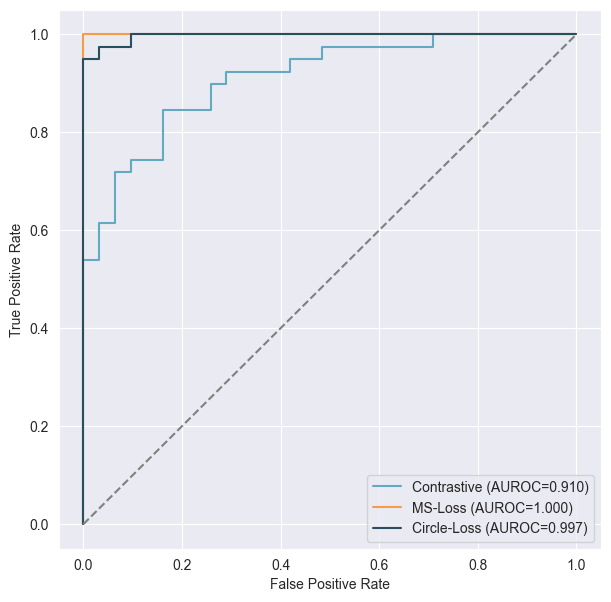

,accuracy,precision,recall,F1,AUROC,AUPRC,opt_threshold
model,,,,,,,
Contrastive,0.829,0.814,0.897,0.854,0.910,0.935,0.256
MS-Loss,0.986,1.000,0.974,0.987,1.000,1.000,-0.350
Circle-Loss,0.971,1.000,0.949,0.974,0.997,0.998,-0.359


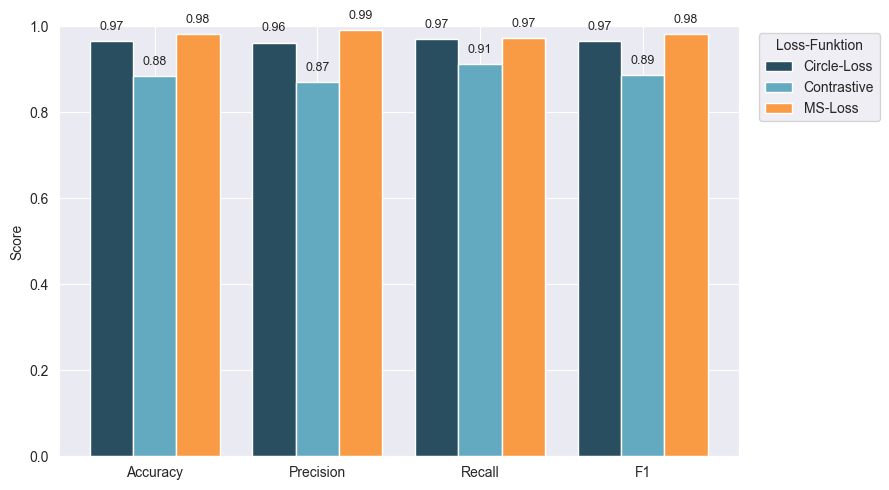

'\nif {\'MS-Loss\',\'Circle-Loss\'}.issubset(cv_results.index.get_level_values(0)):\n    ms_vals = cv_results.loc[\'MS-Loss\', \'AUROC\']\n    circle_vals = cv_results.loc[\'Circle-Loss\', \'AUROC\']\n    stat, p = wilcoxon(ms_vals.values, circle_vals.values)\n    print(f"\nWilcoxon AUROC MS-Loss vs. Circle-Loss: p = {p:.4f}")\nelse:\n    print("\nWilcoxon skipped – required keys missing.")\n'

In [22]:
# =============================================================================
# 0) Imports
# =============================================================================
import warnings
from sklearn.exceptions import UndefinedMetricWarning
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

from scipy.stats import wilcoxon
import torch
import torch.nn.functional as F
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import (
    roc_curve, auc, average_precision_score,
    confusion_matrix, accuracy_score, f1_score,
    precision_score, recall_score
)

# =============================================================================
# Color mapping for consistent use in ROC and bar plots
# =============================================================================
colors = {
    "Contrastive": "#63AAC0",   # Contrastive Loss
    "MS-Loss":    "#F99B45",   # MS Loss
    "Circle-Loss":"#284E60"    # Circle Loss
}

# -----------------------------------------------------------------------------
# 1) Standard collect_scores für CV (arbeitet mit DataLoader)
# -----------------------------------------------------------------------------
def collect_scores(model, dataloader, device, sim='cosine'):
    model.eval()
    scores, labels = [], []
    with torch.no_grad():
        for img1, img2, lbl, *_ in dataloader:
            img1, img2 = img1.to(device), img2.to(device)
            e1, e2 = model(img1, img2)
            if sim == 'cosine':
                s = -F.cosine_similarity(e1, e2)  # flip so larger→dissimilar
            else:
                s = F.pairwise_distance(e1, e2)
            scores.extend(s.cpu().numpy())
            labels.extend(lbl.view(-1).cpu().numpy())
    return np.asarray(scores), np.asarray(labels)

# -----------------------------------------------------------------------------
# 2) collect_scores_fixed für finale Auswertung (arbeitet mit fixed_pairs)
# -----------------------------------------------------------------------------
def collect_scores_fixed(model, pairs, sim='cosine'):
    model.eval()
    scores, labels = [], []
    with torch.no_grad():
        for img1, img2, lbl in pairs:
            e1, e2 = model(img1, img2)
            if sim == 'cosine':
                s = -F.cosine_similarity(e1, e2)
            else:
                s = F.pairwise_distance(e1, e2)
            scores.extend(s.cpu().numpy())
            labels.extend(lbl.view(-1).cpu().numpy())
    return np.asarray(scores), np.asarray(labels)

# -----------------------------------------------------------------------------
# 3) Compute scalar metrics at a given threshold
# -----------------------------------------------------------------------------
def metrics_at_threshold(scores, labels, thr):
    preds = scores > thr  # 1 = dissimilar
    return (
        accuracy_score(labels, preds),
        precision_score(labels, preds, zero_division=0),
        recall_score(labels, preds, zero_division=0),
        f1_score(labels, preds, zero_division=0)
    )

# -----------------------------------------------------------------------------
# 4) Evaluation for CV: nimmt DataLoader
# -----------------------------------------------------------------------------
def evaluate_models(model_dict, dataloader, device, show_plot=True, show_cm=True):
    rows = []
    if show_plot:
        plt.figure(figsize=(7,7))
    for name, (model, sim) in model_dict.items():
        scores, labels = collect_scores(model, dataloader, device, sim=sim)
        fpr, tpr, thr = roc_curve(labels, scores)
        if show_plot:
            plt.plot(fpr, tpr,
                     label=f"{name} (AUROC={auc(fpr,tpr):.3f})",
                     color=colors[name])
        # find best F1 threshold
        f1s = [metrics_at_threshold(scores, labels, t)[-1] for t in thr]
        best_thr = thr[int(np.nanargmax(f1s))]
        acc, prec, rec, f1 = metrics_at_threshold(scores, labels, best_thr)
        auprc = average_precision_score(labels, scores)
        rows.append({
            'model': name,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'F1': f1,
            'AUROC': auc(fpr,tpr),
            'AUPRC': auprc,
            'opt_threshold': float(best_thr)
        })
        if show_cm:
            cm = confusion_matrix(labels, scores > best_thr)
            print(f"\nConfusion Matrix – {name} (thr={best_thr:.3f})\n", cm)
    if show_plot:
        plt.plot([0,1], [0,1], '--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC comparison – all models")
        plt.legend()
        plt.grid(True)
        plt.show()
    return pd.DataFrame(rows).set_index('model').round(3)

# -----------------------------------------------------------------------------
# 5) Evaluation final: benutzt fixed_pairs
# -----------------------------------------------------------------------------
def evaluate_models_fixed(model_dict, pairs, show_plot=True, show_cm=True):
    rows = []
    if show_plot:
        plt.figure(figsize=(7,7))
    for name, (model, sim) in model_dict.items():
        scores, labels = collect_scores_fixed(model, pairs, sim=sim)
        fpr, tpr, thr = roc_curve(labels, scores)
        if show_plot:
            plt.plot(fpr, tpr,
                     label=f"{name} (AUROC={auc(fpr,tpr):.3f})",
                     color=colors[name])
        f1s = [metrics_at_threshold(scores, labels, t)[-1] for t in thr]
        best_thr = thr[int(np.nanargmax(f1s))]
        acc, prec, rec, f1 = metrics_at_threshold(scores, labels, best_thr)
        auprc = average_precision_score(labels, scores)
        rows.append({
            'model': name,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'F1': f1,
            'AUROC': auc(fpr,tpr),
            'AUPRC': auprc,
            'opt_threshold': float(best_thr)
        })
        if show_cm:
            cm = confusion_matrix(labels, scores > best_thr)
            print(f"\nConfusion Matrix – {name} (thr={best_thr:.3f})\n", cm)
    if show_plot:
        plt.plot([0,1], [0,1], '--', color='gray')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        # plt.title("ROC comparison – fixed samples")
        plt.legend()
        plt.grid(True)
        plt.show()
    return pd.DataFrame(rows).set_index('model').round(3)

# -----------------------------------------------------------------------------
# 6) Load models
# -----------------------------------------------------------------------------
from src.ml.resNet18 import SiameseNetworkCosine, SiameseNetworkContrastive

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_paths = {
    "Contrastive":   "models/models_contrastive/best_model_overall.pt",
    "MS-Loss":       "models/models_ms/models_ms_40_80/best_model_overall.pt",
    "Circle-Loss":   "models/models_circle/best_model_overall.pt"
}
models_to_compare = {}
for name, path in model_paths.items():
    if name == "Contrastive":
        net = SiameseNetworkContrastive().to(DEVICE)
        sim = 'euclid'
    else:
        net = SiameseNetworkCosine().to(DEVICE)
        sim = 'cosine'
    net.load_state_dict(torch.load(path, map_location=DEVICE), strict=False)
    models_to_compare[name] = (net, sim)

# -----------------------------------------------------------------------------
# 7) Cross-validation / multi-seed loop (silent)
# -----------------------------------------------------------------------------
fold_seeds = list(range(99))
fold_results = []
for seed in fold_seeds:
    g = torch.Generator().manual_seed(seed)
    loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                        num_workers=0, generator=g)
    one_fold = evaluate_models(models_to_compare, loader, DEVICE,
                               show_plot=False, show_cm=False)
    one_fold['fold'] = seed
    fold_results.append(one_fold)
cv_results = pd.concat(fold_results)

# -----------------------------------------------------------------------------
# 8) Display CV summary
# -----------------------------------------------------------------------------
summary = (
    cv_results.reset_index()
              .groupby('model')
              .agg(['mean','std'])
              .round(3)
)
display(summary)

# -----------------------------------------------------------------------------
# 9) Final fixed-sample evaluation
# -----------------------------------------------------------------------------
g0 = torch.Generator().manual_seed(0)
fixed_loader = DataLoader(test_dataset, batch_size=1, shuffle=False,
                          num_workers=0, generator=g0)
fixed_pairs = [
    (i1.to(DEVICE), i2.to(DEVICE), lb.to(DEVICE))
    for i1, i2, lb, *_ in fixed_loader
]
summary_fixed = evaluate_models_fixed(models_to_compare, fixed_pairs,
                                      show_plot=True, show_cm=True)
display(summary_fixed)

# -----------------------------------------------------------------------------
# 9b) Grouped Bar Chart für mean-summary über CV-Folds
# -----------------------------------------------------------------------------
# Ziehe die Mittelwerte (level=1) aller Metriken heraus: mean_summary
mean_summary = summary.xs('mean', axis=1, level=1)[['accuracy','precision','recall','F1']]

import numpy as np
import matplotlib.pyplot as plt

def plot_grouped_metrics(summary_df):
    """Grouped bar chart: für jede Metrik vier Balken (je Loss-Funktion)."""
    metrics = ['accuracy', 'precision', 'recall', 'F1']
    models = summary_df.index.tolist()

    n_metrics = len(metrics)
    n_models = len(models)
    bar_width = 0.8 / n_models
    x = np.arange(n_metrics)

    plt.figure(figsize=(9,5))
    for i, model in enumerate(models):
        values = summary_df.loc[model, metrics].values
        bars = plt.bar(
            x + i*bar_width,
            values,
            width=bar_width,
            label=model,
            color=colors[model]
        )
        # Werte über die Balken schreiben
        for bar in bars:
            h = bar.get_height()
            plt.text(
                bar.get_x() + bar.get_width()/2,
                h + 0.02,
                f"{h:.2f}",
                ha='center', va='bottom', fontsize=9
            )

    plt.xticks(
        x + bar_width*(n_models-1)/2,
        ['Accuracy','Precision','Recall','F1'],
        rotation=0
    )
    plt.ylim(0, 1)
    plt.ylabel('Score')
    plt.legend(title='Loss-Funktion', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Aufruf direkt hier:
plot_grouped_metrics(mean_summary)

# -----------------------------------------------------------------------------
# 10) Wilcoxon test (MS vs Circle) on CV AUROCs
# -----------------------------------------------------------------------------
'''
if {'MS-Loss','Circle-Loss'}.issubset(cv_results.index.get_level_values(0)):
    ms_vals = cv_results.loc['MS-Loss', 'AUROC']
    circle_vals = cv_results.loc['Circle-Loss', 'AUROC']
    stat, p = wilcoxon(ms_vals.values, circle_vals.values)
    print(f"\nWilcoxon AUROC MS-Loss vs. Circle-Loss: p = {p:.4f}")
else:
    print("\nWilcoxon skipped – required keys missing.")
'''


# Test 1 Matrix with Threshold

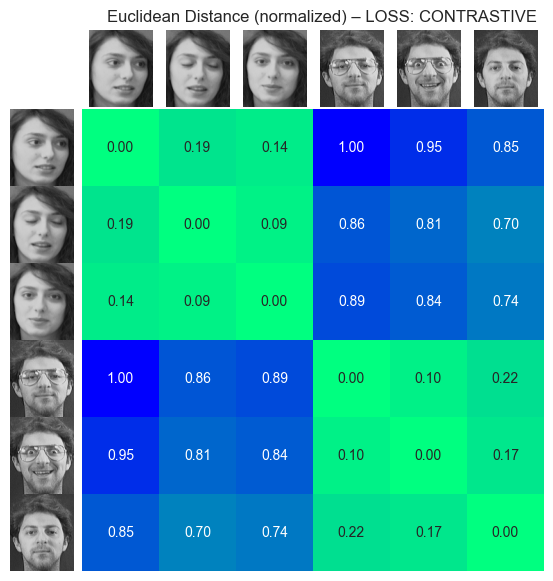

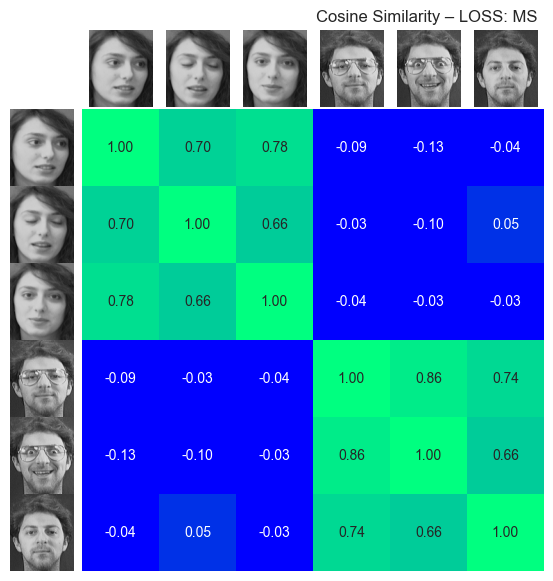

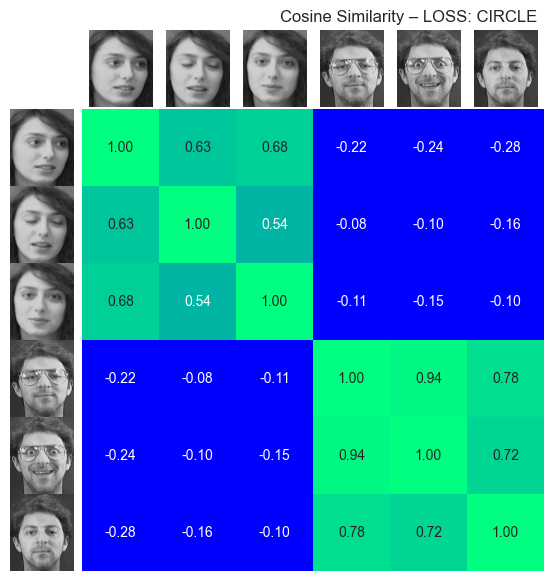

In [23]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torchvision")

import random
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from PIL import Image
from collections import defaultdict

# -----------------------------------------------------------------------------
# Blue→green gamma‐corrected colormap (fixed regardless of metric)
# -----------------------------------------------------------------------------
orig_cmap    = plt.colormaps.get_cmap("winter")
gamma        = 0.55
colors       = orig_cmap(np.linspace(0, 1, 256) ** gamma)
blue2green   = mcolors.ListedColormap(colors)
blue2green_r = blue2green.reversed()  # invertiertes Colormap

# -----------------------------------------------------------------------------
# Metric computation (jetzt mit Loss‐Type‐Argument)
# -----------------------------------------------------------------------------
def compute_matrix(embeddings, loss_type):
    if loss_type == "CONTRASTIVE":
        dists = torch.cdist(embeddings, embeddings, p=2)
        dists.fill_diagonal_(0.0)
        norm_dists = dists / dists.max()
        return norm_dists.cpu().numpy(), "Euclidean Distance (normalized)", True
    else:
        emb = F.normalize(embeddings, p=2, dim=1)
        sims = emb @ emb.T
        sims.fill_diagonal_(1.0)
        return sims.cpu().numpy(), "Cosine Similarity", False

# -----------------------------------------------------------------------------
# Add thumbnails (unverändert)
# -----------------------------------------------------------------------------
def add_thumbnails(ax, images, side="left", pad=0.003):
    fig, n     = ax.figure, len(images)
    axpos      = ax.get_position()
    cell_size  = (axpos.height if side=="left" else axpos.width) / n

    for i, img in enumerate(images):
        if side == "left":
            x0 = axpos.x0 - pad - cell_size
            y0 = axpos.y0 + axpos.height - (i+1)*cell_size
        else:
            x0 = axpos.x0 + i*cell_size
            y0 = axpos.y1 + pad
        thumb = fig.add_axes([x0, y0, cell_size, cell_size])
        thumb.imshow(np.asarray(img))
        thumb.axis("off")

# -----------------------------------------------------------------------------
# Step 1: sample once 2×5 Bilder aus folder_dataset_test
# -----------------------------------------------------------------------------
cls2paths = defaultdict(list)
for path, lbl in folder_dataset_test.imgs:
    cls2paths[lbl].append(path)
valid_classes = [c for c,lst in cls2paths.items() if len(lst) >= 3]
assert len(valid_classes) >= 2, "Need ≥2 classes with ≥5 images each!"

cls_a, cls_b = random.sample(valid_classes, 2)
paths = random.sample(cls2paths[cls_a], 3) + random.sample(cls2paths[cls_b], 3)
pil_images = [Image.open(p).convert("RGB") for p in paths]

# -----------------------------------------------------------------------------
# Modell‐Definitionen
# -----------------------------------------------------------------------------
from src.ml.resNet18 import SiameseNetworkCosine, SiameseNetworkContrastive
model_map = {
    "CONTRASTIVE": "models/models_contrastive/best_model_overall.pt",
    "MS":           "models/models_ms/models_ms_40_80/best_model_overall.pt",
    "CIRCLE":       "models/models_circle/best_model_overall.pt"
}
loss_seq = ["CONTRASTIVE", "MS", "CIRCLE"]

# -----------------------------------------------------------------------------
# Für jeden LOSS_TYPE einzeln plotten
# -----------------------------------------------------------------------------
for lt in loss_seq:
    # Modell laden
    if lt == "CONTRASTIVE":
        net = SiameseNetworkContrastive().to(DEVICE)
    else:
        net = SiameseNetworkCosine().to(DEVICE)
    net.load_state_dict(torch.load(model_map[lt], map_location=DEVICE), strict=False)
    net.eval()

    # Embeddings berechnen
    with torch.no_grad():
        batch = torch.stack([transformation_test(im) for im in pil_images]).to(DEVICE)
        embeddings = net.forward_once(batch)

    # Matrix & Label
    matrix, metric_label, is_dist = compute_matrix(embeddings, lt)

    # Plot erzeugen
    fig = plt.figure(figsize=(6, 6))
    ax  = sns.heatmap(
        matrix,
        cmap=blue2green_r if is_dist else blue2green,
        vmin=0, vmax=1,
        square=True,
        annot=True, fmt=".2f",
        cbar=False,
        xticklabels=False, yticklabels=False
    )
    add_thumbnails(ax, pil_images, side="left")
    add_thumbnails(ax, pil_images, side="top")
    plt.title(f"{metric_label} – LOSS: {lt}", fontsize=12, loc="right")
    plt.show()